In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join
from torch.nn import Conv2d
from os import makedirs
from os.path import splitext, basename
import torch
import math
from matplotlib.ticker import FuncFormatter
import autrainer
from autrainer.serving import Inference
from autrainer.models.cnn_10 import Cnn10
from autrainer.models import TorchvisionModel

autrainer.__version__

/home/manuel/cloned_repos/transfer_learning_evaluation/TL_experiments_thesis/updated_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def calculate_cosine_distances(all_weights_1, all_weights_2):
    cosine_distances = []
    for (w1, w2) in zip(all_weights_1, all_weights_2):
        w1 = w1.ravel()
        w2 = w2.ravel()
        dot = np.dot(w1, w2)
        norms = np.linalg.norm(w1) * np.linalg.norm(w2)
        cosine_similarity_np = dot / norms
        cosine_distance_np = 1.0 - cosine_similarity_np
        cosine_distances.append(cosine_distance_np)
    return cosine_distances

def calculate_cosine_distances_variable(all_weights_1, all_weights_2, calculate_mean=False):
    cosine_distances = []
    # for models, in which weights are given as a list of multiple tensors (like for the Cnn10 implementation below)
    if isinstance(all_weights_1, list):
        for w1, w2 in zip(all_weights_1, all_weights_2):
            if calculate_mean:
                cosine_distances += calculate_cosine_distances(w1, w2)
            else:
                cosine_distances.append(np.mean(calculate_cosine_distances(w1, w2)))
    # for models, which provide directly the weights as a single tensor
    else:
        cosine_distances = calculate_cosine_distances(all_weights_1, all_weights_2)
    if calculate_mean:
        return np.mean(cosine_distances)
    else:
        return cosine_distances

def calculate_cosine_distance_cnn10(state1, state2, calculate_mean=False):
    model1 = Cnn10(10)
    model2 = Cnn10(10)
    model1.eval()
    model2.eval()
    model1.load_state_dict(state1)
    model2.load_state_dict(state2)
    all_weights_model1 = []
    for m in model1.modules():
        if isinstance(m, Conv2d):
            w = m.weight.detach().cpu().numpy()
            all_weights_model1.append(w)
    all_weights_model2 = []
    for m in model2.modules():
        if isinstance(m, Conv2d):
            w = m.weight.detach().cpu().numpy()
            all_weights_model2.append(w)
    # get all cosine distances per layer
    cosine_distances = calculate_cosine_distances_variable(all_weights_model1, all_weights_model2, calculate_mean=calculate_mean)
    return cosine_distances

In [7]:
model_state_dir = "model_states"
model_paths = glob(join(model_state_dir, "*"))
model_names = []
model_dict = {}
# Load model states for all pre-trained states 
for model_path in model_paths:
    model_name = splitext(basename(model_path))[0]
    print(basename(model_name))
    if "None" in model_name:
        model_name = "None"
    elif "AS-P" in model_name:
        model_name = "AS"
    else:
        model_name = ("-".join(model_name.split("-")[2:-1])).capitalize()
    model_names.append(model_name)
    model_state = torch.load(model_path, map_location=torch.device('cpu'))
    model_dict[model_name] = model_state
model_names.sort()


Cnn10-AS-speech-P
Cnn10-AS-0.03-P
Cnn10-AS-naturalsources-P
Cnn10-None
Cnn10-AS-humansounds-P
Cnn10-AS-nature-P
Cnn10-AS-0.3-P
Cnn10-AS-animal-P
Cnn10-AS-0.01-P
Cnn10-AS-nonhuman-P
Cnn10-AS-things-P
Cnn10-AS-0.1-P
Cnn10-AS-P
Cnn10-AS-naturalsounds-P


In [8]:
c_mean = False

n = len(model_names)
dist_matrix = np.zeros((n, n))

# define the layer of which we want to calculate the cosine-distance
plot_layer = 0

for i in range(n):
    for j in range(n):
        state1 = model_dict[model_names[i]]
        state2 = model_dict[model_names[j]]
        cosine_distance = calculate_cosine_distance_cnn10(state1, state2, calculate_mean=c_mean)
        if not c_mean:
            cosine_distance = np.abs(cosine_distance[plot_layer])
        dist_matrix[i, j] = cosine_distance                                                

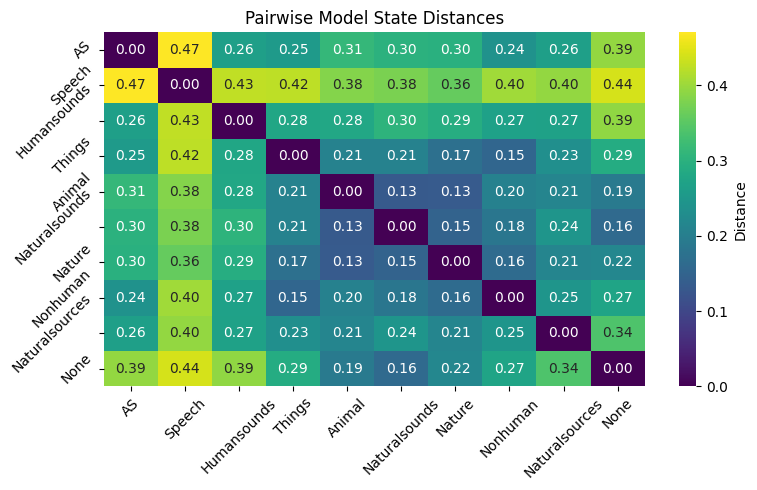

In [10]:
# Subset for which to plot the pairwise cosine distance matrix - here only for ontology-based subsets
subset = ['AS', 'Speech', 'Humansounds', 'Things', 'Animal', 'Naturalsounds', 'Nature', 'Nonhuman', 'Naturalsources', 'None']

df_dist = pd.DataFrame(dist_matrix, index=model_names, columns=model_names)
df_subset = df_dist.loc[subset, subset]

# plot parameters

# uncomment for latex style text
# plt.rcParams["text.usetex"] = True
# plt.rc('text', usetex=True)
# plt.rc('font', family='serif')

n_datasets = 4
n_models = 2
n_pretraining_datasets = 2
n_pretrained_models = 5

label_font_size = 20
legend_font_size = 16
tick_font_size = 18
text_marker_font_size = 14

line_width = 2
marker_size = 9

outdir = "plots"

makedirs(outdir, exist_ok=True)
file_ext1 = ".pdf"
file_ext2 = ".png"


plt.figure(figsize=(8, 5))
sns.heatmap(df_subset, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'Distance'})
plt.title("Pairwise Model State Distances")
plt.yticks(rotation=45)
plt.xticks(rotation=45)
plt.tight_layout()
out_path = join(outdir, "pairwise_cosine_distance")
#out_path = join(outdir, "pairwise_cosine_distance" + str(c_mean) + ".png")
plt.savefig(out_path + file_ext1)
plt.savefig(out_path + file_ext2)
plt.show()